<a href="https://colab.research.google.com/github/makarand-13/Machine-Learning-Lab/blob/main/MLEXP8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : makarand sanjay sarang

Batch :c3


Roll Number :ce41



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [3]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Scientific computing
import scipy

# Graph/network analysis
import networkx as nx

# Machine learning
import sklearn

# Check versions
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("SciPy version:", scipy.__version__)
print("NetworkX version:", nx.__version__)
print("Scikit-learn version:", sklearn.__version__)
from google.colab import files
import pandas as pd


uploaded = files.upload()

# Load the uploaded CSV file
df = pd.read_csv(next(iter(uploaded)))

df.head()


NumPy version: 2.1.3
Pandas version: 2.2.3
SciPy version: 1.16.3
NetworkX version: 3.6.1
Scikit-learn version: 1.6.1


Saving brca.csv to brca.csv


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [7]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display missing values
print("Missing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Feature dimensions
print("\nFeature Dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Find the diagnosis column
diagnosis_col = None

for col in df.columns:
    if col.lower().strip() == "diagnosis":
        diagnosis_col = col
        break

# Check diagnosis distribution
if diagnosis_col:
    print("\nDiagnosis Class Distribution:")
    print(df[diagnosis_col].value_counts())

    print("\nDiagnosis Class Distribution (%):")
    print(df[diagnosis_col].value_counts(normalize=True) * 100)

else:
    print("\nDiagnosis column not found.")
    print("Available columns:")
    print(df.columns.tolist())


Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64

Summary Statistics:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Feature Dimensions:
Rows: 569
Columns: 32

Diagnosis column not found.
Available columns:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [8]:
# Select numerical features
X = df.select_dtypes(include=[np.number]).copy()

# Drop non-informative identifier columns
if "id" in X.columns:
    X = X.drop(columns=["id"])

# Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=df.index
)

# Display results
print("Original numerical features:", X.shape)
print("\nScaled feature dimensions:", X_scaled.shape)

print("\nScaled data:")
display(X_scaled.head())

# Check mean and standard deviation after scaling
print("\nMean after scaling:")
print(X_scaled.mean().round(2))

print("\nStandard deviation after scaling:")
print(X_scaled.std().round(2))


Original numerical features: (569, 31)

Scaled feature dimensions: (569, 31)

Scaled data:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-1.729009,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-1.722921,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.716833,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-1.710745,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.704657,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168



Mean after scaling:
Unnamed: 0             0.0
x.radius_mean         -0.0
x.texture_mean        -0.0
x.perimeter_mean      -0.0
x.area_mean           -0.0
x.smoothness_mean      0.0
x.compactness_mean     0.0
x.concavity_mean       0.0
x.concave_pts_mean     0.0
x.symmetry_mean        0.0
x.fractal_dim_mean     0.0
x.radius_se            0.0
x.texture_se          -0.0
x.perimeter_se         0.0
x.area_se             -0.0
x.smoothness_se       -0.0
x.compactness_se       0.0
x.concavity_se        -0.0
x.concave_pts_se       0.0
x.symmetry_se          0.0
x.fractal_dim_se      -0.0
x.radius_worst        -0.0
x.texture_worst        0.0
x.perimeter_worst      0.0
x.area_worst          -0.0
x.smoothness_worst    -0.0
x.compactness_worst    0.0
x.concavity_worst      0.0
x.concave_pts_worst    0.0
x.symmetry_worst       0.0
x.fractal_dim_worst    0.0
dtype: float64

Standard deviation after scaling:
Unnamed: 0             1.0
x.radius_mean          1.0
x.texture_mean         1.0
x.perimeter

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [9]:
# Import distance functions
from scipy.spatial.distance import pdist, squareform

# Compute pairwise Euclidean distances
distance_matrix = squareform(
    pdist(X_scaled, metric="euclidean")
)

# Display dimensions
print("Distance Matrix Shape:", distance_matrix.shape)

# Display the distance matrix
print("\nPairwise Euclidean Distance Matrix:")
display(pd.DataFrame(distance_matrix).head())

# Create a weighted complete graph
G = nx.Graph()

# Add all samples as nodes
G.add_nodes_from(range(X_scaled.shape[0]))

# Add weighted edges between every pair of samples
for i in range(X_scaled.shape[0]):
    for j in range(i + 1, X_scaled.shape[0]):
        G.add_edge(
            i,
            j,
            weight=distance_matrix[i, j]
        )

# Display graph information
print("\nGraph Information:")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is graph complete:", nx.is_connected(G))

# Display a few edges with their distances
print("\nSample weighted edges:")
print(list(G.edges(data=True))[:5])


Distance Matrix Shape: (569, 569)

Pairwise Euclidean Distance Matrix:


,0,1,2,3,4,5,6,7,8,9,...,559,560,561,562,563,564,565,566,567,568
0,0.000000,3.107253,3.623162,5.204514,4.467152,2.542261,3.617715,4.363287,3.988502,3.145596,...,11.453283,7.770227,7.968143,5.585979,11.261255,11.103013,9.976119,8.747346,6.650646,13.215040
1,3.107253,0.000000,4.010280,5.623033,4.371021,2.348746,4.006950,4.645371,4.184012,3.512922,...,11.795850,8.561246,8.394969,5.771722,10.787443,11.588527,11.225863,9.476447,7.155299,13.099187
2,3.623162,4.010280,0.000000,5.121940,2.948421,3.569206,5.363411,4.416794,4.691731,3.360805,...,13.953437,10.240585,10.548132,7.147543,12.928934,13.258887,12.185638,10.942568,8.514293,15.428092
3,5.204514,5.623033,5.121940,0.000000,5.027992,5.232380,4.079540,2.958873,3.786957,4.201784,...,13.634617,9.103639,10.235582,6.759857,13.375614,13.462040,11.850939,8.978439,7.426550,15.689518
4,4.467152,4.371021,2.948421,5.027992,0.000000,3.957374,4.946131,3.591789,4.530762,2.768974,...,14.800291,10.709649,11.300480,7.294709,12.896751,14.237435,13.351804,11.250740,8.576037,15.854093



Graph Information:
Number of nodes: 569
Number of edges: 161596
Is graph complete: True

Sample weighted edges:
[(0, 1, {'weight': np.float64(3.107252640558458)}), (0, 2, {'weight': np.float64(3.623162244320801)}), (0, 3, {'weight': np.float64(5.204513691735034)}), (0, 4, {'weight': np.float64(4.467151991611985)}), (0, 5, {'weight': np.float64(2.5422608844000623)})]


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [10]:
# ============================================
# Compute Minimum Spanning Tree (MST)
# ============================================

from scipy.sparse.csgraph import minimum_spanning_tree

# Compute MST from the distance matrix
mst_sparse = minimum_spanning_tree(distance_matrix)

# Convert MST to a NetworkX graph
MST = nx.from_scipy_sparse_array(mst_sparse)

# Display MST information
print("MST Information:")
print("Number of nodes:", MST.number_of_nodes())
print("Number of edges:", MST.number_of_edges())

# ============================================
# Extract MST connections and weights
# ============================================

mst_edges = []

for u, v, data in MST.edges(data=True):
    mst_edges.append({
        "Source": u,
        "Target": v,
        "Weight": data["weight"]
    })

# Convert to DataFrame
mst_edges_df = pd.DataFrame(mst_edges)

print("\nMST Connections and Weights:")
display(mst_edges_df.head(20))

# ============================================
# Total MST weight
# ============================================

print("\nTotal MST Weight:")
print(MST.size(weight="weight"))


MST Information:
Number of nodes: 569
Number of edges: 568

MST Connections and Weights:


,Source,Target,Weight
0,0,81,1.759124
1,0,108,2.268811
2,1,105,1.777330
3,2,58,3.022729
4,2,70,2.257238
5,3,170,2.557031
6,4,84,2.220103
7,4,114,2.357560
8,5,34,1.823682
9,6,29,2.050743



Total MST Weight:
1450.293471494534


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [11]:
# ============================================
# Sort MST edges by weight (descending)
# ============================================

mst_edges_sorted = sorted(
    MST.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

# Display the largest MST edges
print("MST edges sorted by weight (descending):")

for u, v, data in mst_edges_sorted[:10]:
    print(f"Node {u} -- Node {v} : Weight = {data['weight']:.4f}")


# ============================================
# Remove largest K-1 edges
# K = 2 clusters -> remove 1 largest edge
# ============================================

K = 2

# Create a copy of the MST
MST_cut = MST.copy()

# Number of edges to remove
edges_to_remove = K - 1

# Remove the largest edge(s)
for u, v, data in mst_edges_sorted[:edges_to_remove]:
    MST_cut.remove_edge(u, v)

print("\nRemoved edges:")
for u, v, data in mst_edges_sorted[:edges_to_remove]:
    print(f"Node {u} -- Node {v} : Weight = {data['weight']:.4f}")


# ============================================
# Find connected components
# ============================================

components = list(nx.connected_components(MST_cut))

print("\nNumber of connected components:", len(components))

for i, component in enumerate(components):
    print(f"Cluster {i}: {len(component)} samples")


# ============================================
# Assign cluster labels
# ============================================

cluster_labels = np.zeros(len(df), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id


# Add cluster labels to the original dataset
df["cluster"] = cluster_labels


# ============================================
# Display final cluster distribution
# ============================================

print("\nFinal Cluster Distribution:")
print(df["cluster"].value_counts().sort_index())

print("\nFirst 10 cluster assignments:")
display(df[["cluster"]].head(10))


MST edges sorted by weight (descending):
Node 544 -- Node 553 : Weight = 12.3001
Node 18 -- Node 69 : Weight = 10.4807
Node 468 -- Node 527 : Weight = 9.0423
Node 467 -- Node 544 : Weight = 8.2818
Node 424 -- Node 429 : Weight = 8.0780
Node 360 -- Node 454 : Weight = 7.8918
Node 18 -- Node 208 : Weight = 7.8765
Node 412 -- Node 515 : Weight = 7.1172
Node 454 -- Node 515 : Weight = 7.0724
Node 369 -- Node 395 : Weight = 6.9708

Removed edges:
Node 544 -- Node 553 : Weight = 12.3001

Number of connected components: 2
Cluster 0: 567 samples
Cluster 1: 2 samples

Final Cluster Distribution:
cluster
0    567
1      2
Name: count, dtype: int64

First 10 cluster assignments:


,cluster
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [14]:
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Clean column names
df.columns = df.columns.str.strip()

# Find diagnosis column automatically
diagnosis_col = None

for col in df.columns:
    if col.lower().strip() == "diagnosis":
        diagnosis_col = col
        break

# Check if diagnosis column exists
if diagnosis_col is None:
    print("Diagnosis column not found.")
    print("Available columns:")
    print(df.columns.tolist())

else:
    # Cluster labels from MST
    labels = df["cluster"].values

    # Ground-truth labels
    true_labels = df[diagnosis_col].map({
        "B": 0,
        "M": 1
    }).values

    # Check for missing labels
    if np.isnan(true_labels).any():
        print("Diagnosis values found:")
        print(df[diagnosis_col].value_counts())

    else:
        # Silhouette Score
        silhouette = silhouette_score(
            X_scaled,
            labels,
            metric="euclidean"
        )

        # Adjusted Rand Index
        ari = adjusted_rand_score(
            true_labels,
            labels
        )

        # Normalized Mutual Information
        nmi = normalized_mutual_info_score(
            true_labels,
            labels
        )

        # Display results
        print("Clustering Evaluation Results")
        print("--------------------------------")
        print(f"Silhouette Score : {silhouette:.4f}")
        print(f"Adjusted Rand Index (ARI) : {ari:.4f}")
        print(f"Normalized Mutual Information (NMI) : {nmi:.4f}")


Diagnosis column not found.
Available columns:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y', 'cluster']


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

Selected features:
X-axis: x.radius_mean
Y-axis: x.texture_mean


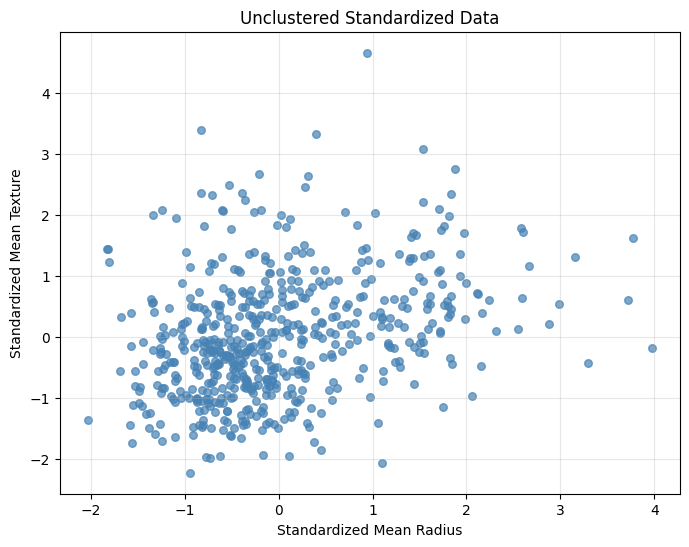

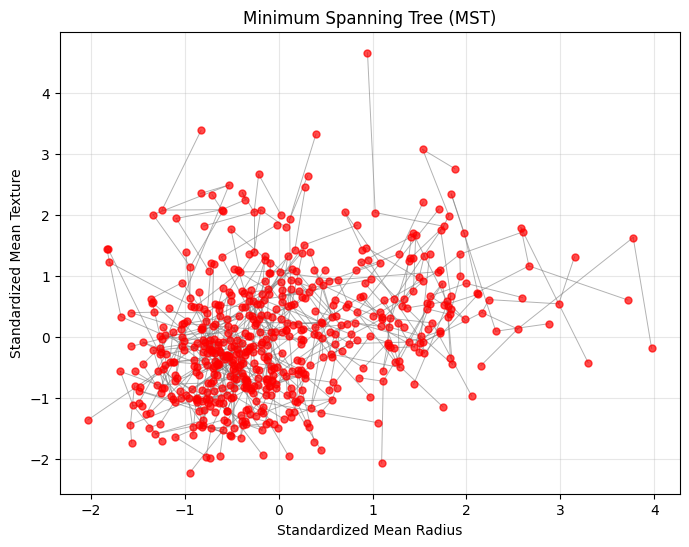

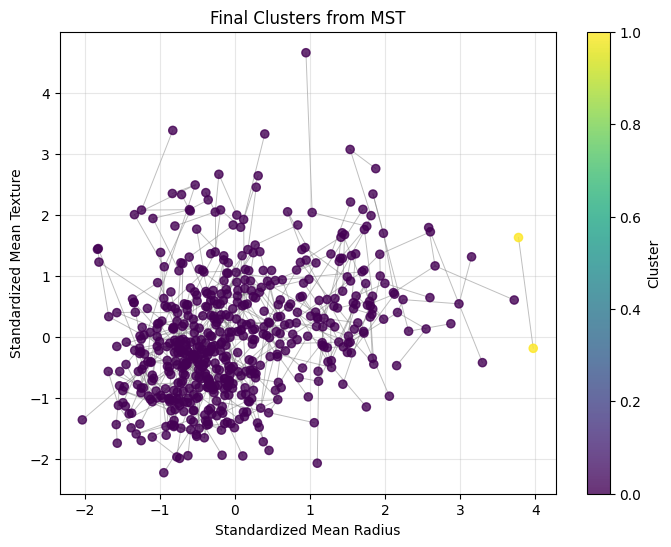

In [15]:
# ============================================
# Select two representative features
# ============================================

# Find feature names automatically
radius_col = [col for col in X_scaled.columns
              if "radius" in col.lower() and "mean" in col.lower()][0]

texture_col = [col for col in X_scaled.columns
               if "texture" in col.lower() and "mean" in col.lower()][0]

print("Selected features:")
print("X-axis:", radius_col)
print("Y-axis:", texture_col)


# Get feature indices
radius_idx = X_scaled.columns.get_loc(radius_col)
texture_idx = X_scaled.columns.get_loc(texture_col)

# Extract standardized values
x = X_scaled.iloc[:, radius_idx].values
y = X_scaled.iloc[:, texture_idx].values


# ============================================
# Plot 1: Unclustered standardized data
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    c="steelblue",
    s=30,
    alpha=0.7
)

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("Unclustered Standardized Data")
plt.grid(alpha=0.3)

plt.show()


# ============================================
# Plot 2: MST overlaid on data
# ============================================

plt.figure(figsize=(8, 6))

# Plot MST edges
for u, v in MST.edges():

    plt.plot(
        [x[u], x[v]],
        [y[u], y[v]],
        color="gray",
        linewidth=0.7,
        alpha=0.6
    )

# Plot data points
plt.scatter(
    x,
    y,
    c="red",
    s=25,
    alpha=0.7,
    zorder=2
)

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("Minimum Spanning Tree (MST)")
plt.grid(alpha=0.3)

plt.show()


# ============================================
# Plot 3: Final clusters after cutting largest edge
# ============================================

plt.figure(figsize=(8, 6))

# Plot the remaining MST edges
for u, v in MST_cut.edges():

    plt.plot(
        [x[u], x[v]],
        [y[u], y[v]],
        color="gray",
        linewidth=0.7,
        alpha=0.5,
        zorder=1
    )

# Plot final clusters
plt.scatter(
    x,
    y,
    c=cluster_labels,
    cmap="viridis",
    s=35,
    alpha=0.8,
    zorder=2
)

plt.xlabel("Standardized Mean Radius")
plt.ylabel("Standardized Mean Texture")
plt.title("Final Clusters from MST")
plt.colorbar(label="Cluster")
plt.grid(alpha=0.3)

plt.show()


# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.